# NB07: Synthesis & Publication Figures

**Goal**: Integrate findings from NB01-06 into a coherent narrative. Generate publication-quality summary figures.

**Depends on**: All previous notebook outputs in `data/`

**Outputs**:
- `../figures/fig1_amr_overview.png` — Multi-panel overview figure
- `../figures/fig2_conservation_mechanisms.png` — Conservation by mechanism
- `../figures/fig3_phylo_env.png` — Phylogenetic and environmental patterns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

DATA_DIR = Path('../data')
FIG_DIR = Path('../figures')

plt.rcParams.update({
    'figure.dpi': 200, 'font.size': 10, 'font.family': 'sans-serif',
    'axes.titlesize': 12, 'savefig.bbox': 'tight', 'savefig.dpi': 300,
})

# Load all data
amr = pd.read_csv(DATA_DIR / 'amr_census.csv')
species = pd.read_csv(DATA_DIR / 'amr_species_summary.csv')
print(f"AMR clusters: {len(amr):,}")
print(f"Species with AMR: {len(species):,}")

# Load optional data
try:
    cog_enrich = pd.read_csv(DATA_DIR / 'amr_cog_enrichment.csv')
    print(f"COG enrichment data loaded")
except FileNotFoundError:
    cog_enrich = None

try:
    env_data = pd.read_csv(DATA_DIR / 'amr_by_environment.csv')
    print(f"Environment data loaded")
except FileNotFoundError:
    env_data = None

AMR clusters: 83,008
Species with AMR: 14,723
COG enrichment data loaded
Environment data loaded


## Figure 1: AMR Overview (4-panel)

A: Conservation class distribution (AMR vs baseline)  
B: Species-level AMR count distribution  
C: Top AMR gene families  
D: AMR mechanism breakdown

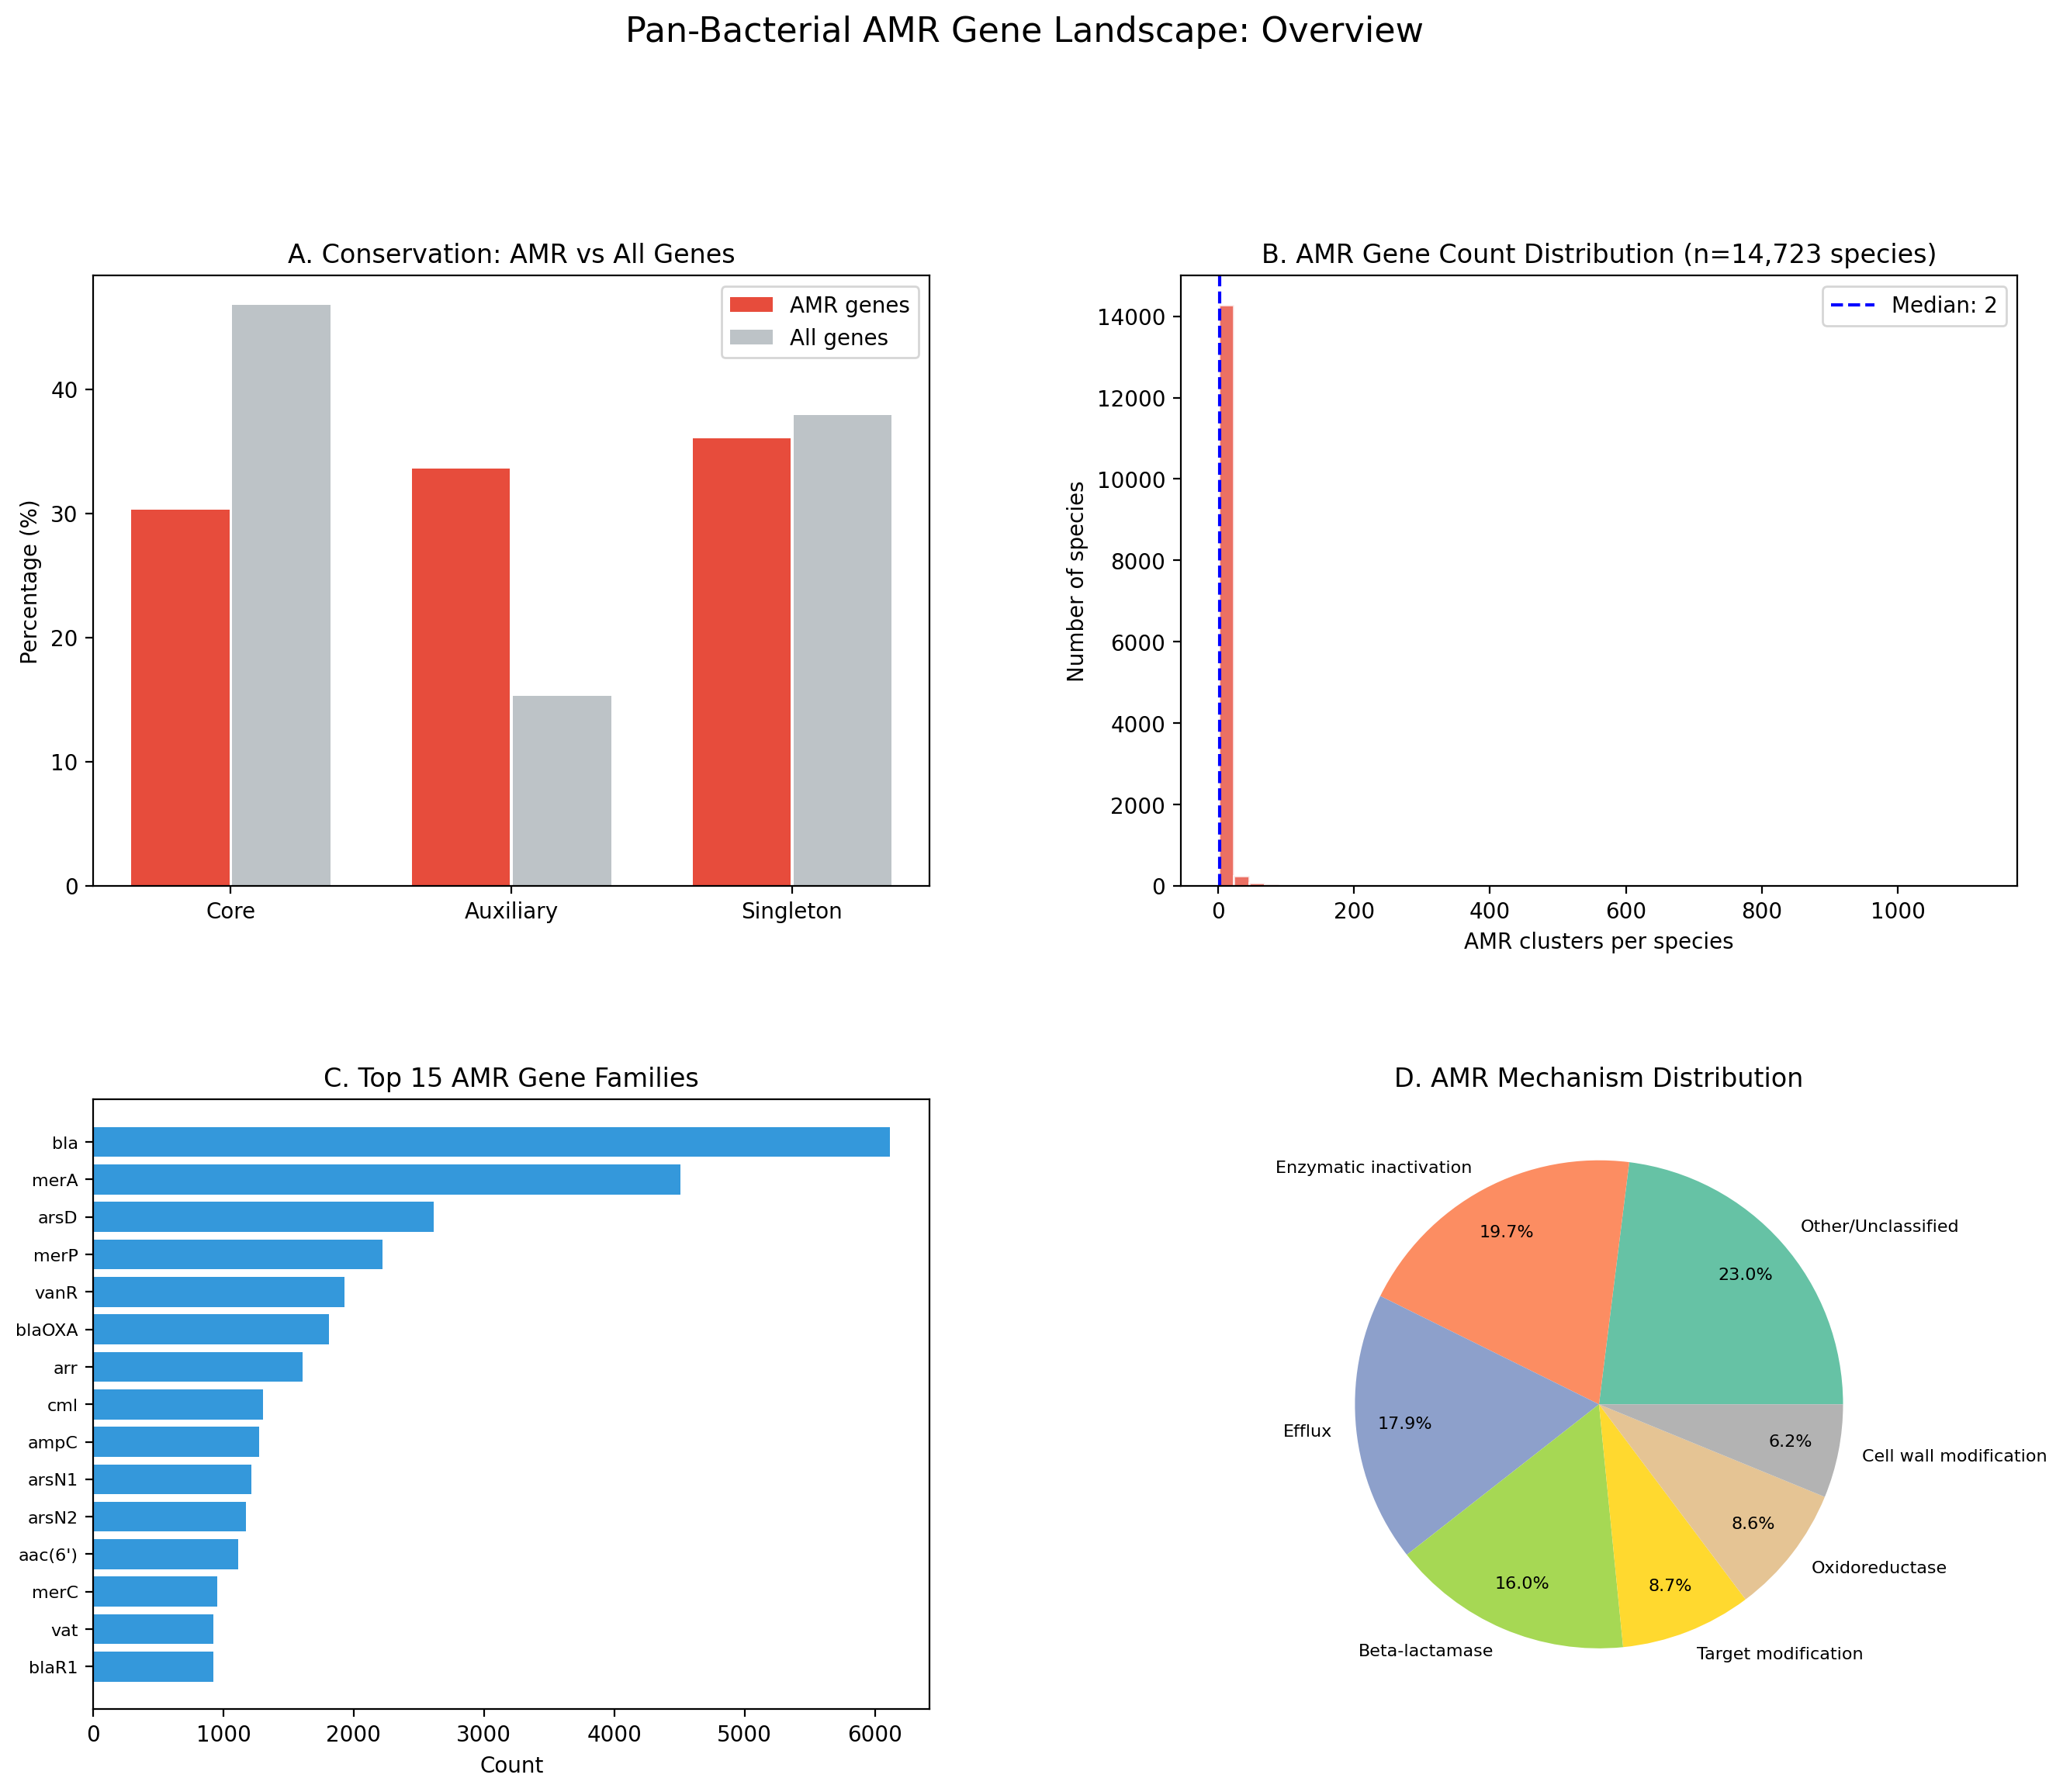

Saved fig1_amr_overview.png


In [2]:
# Derive conservation_class if needed
if 'conservation_class' not in amr.columns:
    amr['conservation_class'] = np.where(
        amr['is_core'], 'Core',
        np.where(amr['is_singleton'], 'Singleton', 'Auxiliary')
    )

# Derive mechanism if needed
if 'mechanism' not in amr.columns:
    def classify_mechanism(product):
        if pd.isna(product): return 'Unknown'
        p = product.lower()
        if any(k in p for k in ['efflux', 'pump', 'transporter', 'exporter']): return 'Efflux'
        if any(k in p for k in ['beta-lactamase', 'lactamase', 'carbapenemase']): return 'Beta-lactamase'
        if any(k in p for k in ['acetyltransferase', 'phosphotransferase', 'nucleotidyltransferase', 'inactivat']): return 'Enzymatic inactivation'
        if any(k in p for k in ['methyltransferase', 'ribosomal protection', 'target protect']): return 'Target modification'
        if any(k in p for k in ['penicillin-binding', 'pbp', 'vancomycin', 'lipid a']): return 'Cell wall modification'
        if any(k in p for k in ['regulator', 'repressor', 'activator']): return 'Regulatory'
        return 'Other'
    amr['mechanism'] = amr['amr_product'].apply(classify_mechanism)

fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, hspace=0.35, wspace=0.3)

# A: Conservation class
ax_a = fig.add_subplot(gs[0, 0])
cons_counts = amr['conservation_class'].value_counts()
baseline_pcts = {'Core': 46.8, 'Auxiliary': 15.3, 'Singleton': 37.9}
classes = ['Core', 'Auxiliary', 'Singleton']
amr_pcts = [cons_counts.get(c, 0) / len(amr) * 100 for c in classes]
base_pcts = [baseline_pcts[c] for c in classes]

x = np.arange(len(classes))
ax_a.bar(x - 0.18, amr_pcts, 0.35, label='AMR genes', color='#e74c3c')
ax_a.bar(x + 0.18, base_pcts, 0.35, label='All genes', color='#bdc3c7')
ax_a.set_xticks(x)
ax_a.set_xticklabels(classes)
ax_a.set_ylabel('Percentage (%)')
ax_a.set_title('A. Conservation: AMR vs All Genes')
ax_a.legend()

# B: Species AMR count distribution
ax_b = fig.add_subplot(gs[0, 1])
ax_b.hist(species['n_amr'], bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
ax_b.set_xlabel('AMR clusters per species')
ax_b.set_ylabel('Number of species')
ax_b.set_title(f'B. AMR Gene Count Distribution (n={len(species):,} species)')
ax_b.axvline(species['n_amr'].median(), color='blue', linestyle='--', 
             label=f'Median: {species["n_amr"].median():.0f}')
ax_b.legend()

# C: Top 15 AMR gene families
ax_c = fig.add_subplot(gs[1, 0])
top_genes = amr['amr_gene'].value_counts().head(15)
top_genes_sorted = top_genes.sort_values()
ax_c.barh(range(len(top_genes_sorted)), top_genes_sorted.values, color='#3498db')
ax_c.set_yticks(range(len(top_genes_sorted)))
ax_c.set_yticklabels(top_genes_sorted.index, fontsize=8)
ax_c.set_xlabel('Count')
ax_c.set_title('C. Top 15 AMR Gene Families')

# D: Mechanism pie chart
ax_d = fig.add_subplot(gs[1, 1])
mech_counts = amr['mechanism'].value_counts().head(7)
colors = plt.cm.Set2(np.linspace(0, 1, len(mech_counts)))
wedges, texts, autotexts = ax_d.pie(mech_counts.values, labels=mech_counts.index,
                                      autopct='%1.1f%%', colors=colors, pctdistance=0.8,
                                      textprops={'fontsize': 8})
ax_d.set_title('D. AMR Mechanism Distribution')

plt.suptitle('Pan-Bacterial AMR Gene Landscape: Overview', fontsize=16, y=1.02)
plt.savefig(FIG_DIR / 'fig1_amr_overview.png')
plt.show()
print("Saved fig1_amr_overview.png")

## Hypothesis Verdict Summary

Fill in after all notebooks have been executed:

In [3]:
# Print summary template — fill in after execution
print("""
=== PAN-BACTERIAL AMR GENE LANDSCAPE — KEY FINDINGS ===

H1 (Conservation): AMR genes are ___% core vs ___% baseline
    → Verdict: [SUPPORTED / NOT REJECTED]
    → OR = ___, chi-squared p = ___

H2 (Phylogeny): Top AMR families are ___
    → ___% of all AMR genes are in Pseudomonadota/Bacillota
    → AMR density correlates with openness: rho = ___

H3 (Functional context): Top enriched COGs are ___
    → ___ enrichment confirms defense-related functional context
    → ___% of AMR genes are in COG category V (Defense)

H4 (Environment): Human/clinical species have ___ mean AMR vs ___ environmental
    → Kruskal-Wallis p = ___

H5 (Annotation depth): ___% of AMR clusters are "AMR-only"
    → AMR-only clusters are ___% singleton vs ___% for annotated

H6 (Fitness cost): AMR genes show mean fitness ___ vs ___ baseline
    → Mann-Whitney p = ___

=== KEY NUMBERS ===
- Total AMR hits: ___
- Species with AMR: ___ / 27,690 (___%)
- Distinct AMR gene families: ___
- Distinct mechanisms: ___
""")


=== PAN-BACTERIAL AMR GENE LANDSCAPE — KEY FINDINGS ===

H1 (Conservation): AMR genes are ___% core vs ___% baseline
    → Verdict: [SUPPORTED / NOT REJECTED]
    → OR = ___, chi-squared p = ___

H2 (Phylogeny): Top AMR families are ___
    → ___% of all AMR genes are in Pseudomonadota/Bacillota
    → AMR density correlates with openness: rho = ___

H3 (Functional context): Top enriched COGs are ___
    → ___ enrichment confirms defense-related functional context
    → ___% of AMR genes are in COG category V (Defense)

H4 (Environment): Human/clinical species have ___ mean AMR vs ___ environmental
    → Kruskal-Wallis p = ___

H5 (Annotation depth): ___% of AMR clusters are "AMR-only"
    → AMR-only clusters are ___% singleton vs ___% for annotated

H6 (Fitness cost): AMR genes show mean fitness ___ vs ___ baseline
    → Mann-Whitney p = ___

=== KEY NUMBERS ===
- Total AMR hits: ___
- Species with AMR: ___ / 27,690 (___%)
- Distinct AMR gene families: ___
- Distinct mechanisms: ___

